In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import sqlite3
from scipy.stats import ttest_ind
import scipy.stats as stats
warnings.filterwarnings('ignore')

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
conn = sqlite3.connect('inventory.db')
df = pd.read_sql_query("SELECT * FROM vendor_sales_summary", conn)
df.head()

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,TotalPurchaseQuantity,TotalPurchaseDollars,FreightCost,Gross_Profit,Profit_Margin,Stock_Turnover,Sales_to_Purchase_Ratio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,23.86,36.99,18.0,665.82,295.92,2.00,8,190.88,27.08,474.94,71.331591,2.250000,3.488160
1,2,"IRA GOLDMAN AND WILLIAMS, LLP",90609,Flavor Essence Variety 5 Pak,17.00,24.99,24.0,599.76,449.82,0.52,320,5440.00,27.08,-4840.24,-807.029478,0.075000,0.110250
2,54,AAPER ALCOHOL & CHEMICAL CO,990,Ethyl Alcohol 200 Proof,105.07,134.49,0.0,0.00,0.00,0.00,1,105.07,0.48,-105.07,0.000000,0.000000,0.000000
3,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,11.44,14.99,47.0,704.53,494.67,37.01,39,446.16,367.52,258.37,36.672675,1.205128,1.579097
4,60,ADAMBA IMPORTS INTL INC,3401,Vesica Vodka,11.10,14.99,0.0,0.00,0.00,0.00,6,66.60,367.52,-66.60,0.000000,0.000000,0.000000


Exploratory Data Analysis

Previously, we examined the various tables in the database to identify key variables, understand their relationships, and determine which ones should be included in the final analysis.

In this phase of EDA, we will analyze the resultant table to gain insights into the distribution of each column. This will help us understand data patterns, identify anomalies, and ensure data quality before proceeding with further analysis.

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
VendorNumber,10692.0,10650.649458,18753.519148,2.000000,3951.000000,7153.000000,9552.000000,2.013590e+05
Brand,10692.0,18039.228769,12662.187074,58.000000,5793.500000,18761.500000,25514.250000,9.063100e+04
PurchasePrice,10692.0,24.385303,109.269375,0.360000,6.840000,10.455000,19.482500,5.681810e+03
ActualPrice,10692.0,35.643671,148.246016,0.490000,10.990000,15.990000,28.990000,7.499990e+03
TotalSalesQuantity,10692.0,3077.482136,10952.851391,0.000000,33.000000,261.000000,1929.250000,3.349390e+05
TotalSalesDollars,10692.0,42239.074419,167655.265984,0.000000,729.220000,5298.045000,28396.915000,5.101920e+06
TotalSalesPrice,10692.0,18793.783627,44952.773386,0.000000,289.710000,2857.800000,16059.562500,6.728193e+05
TotalExciseTax,10692.0,1774.226259,10975.582240,0.000000,4.800000,46.570000,418.650000,3.682428e+05
TotalPurchaseQuantity,10692.0,3140.886831,11095.086769,1.000000,36.000000,262.000000,1975.750000,3.376600e+05
TotalPurchaseDollars,10692.0,30106.693372,123067.799627,0.710000,453.457500,3655.465000,20738.245000,3.811252e+06


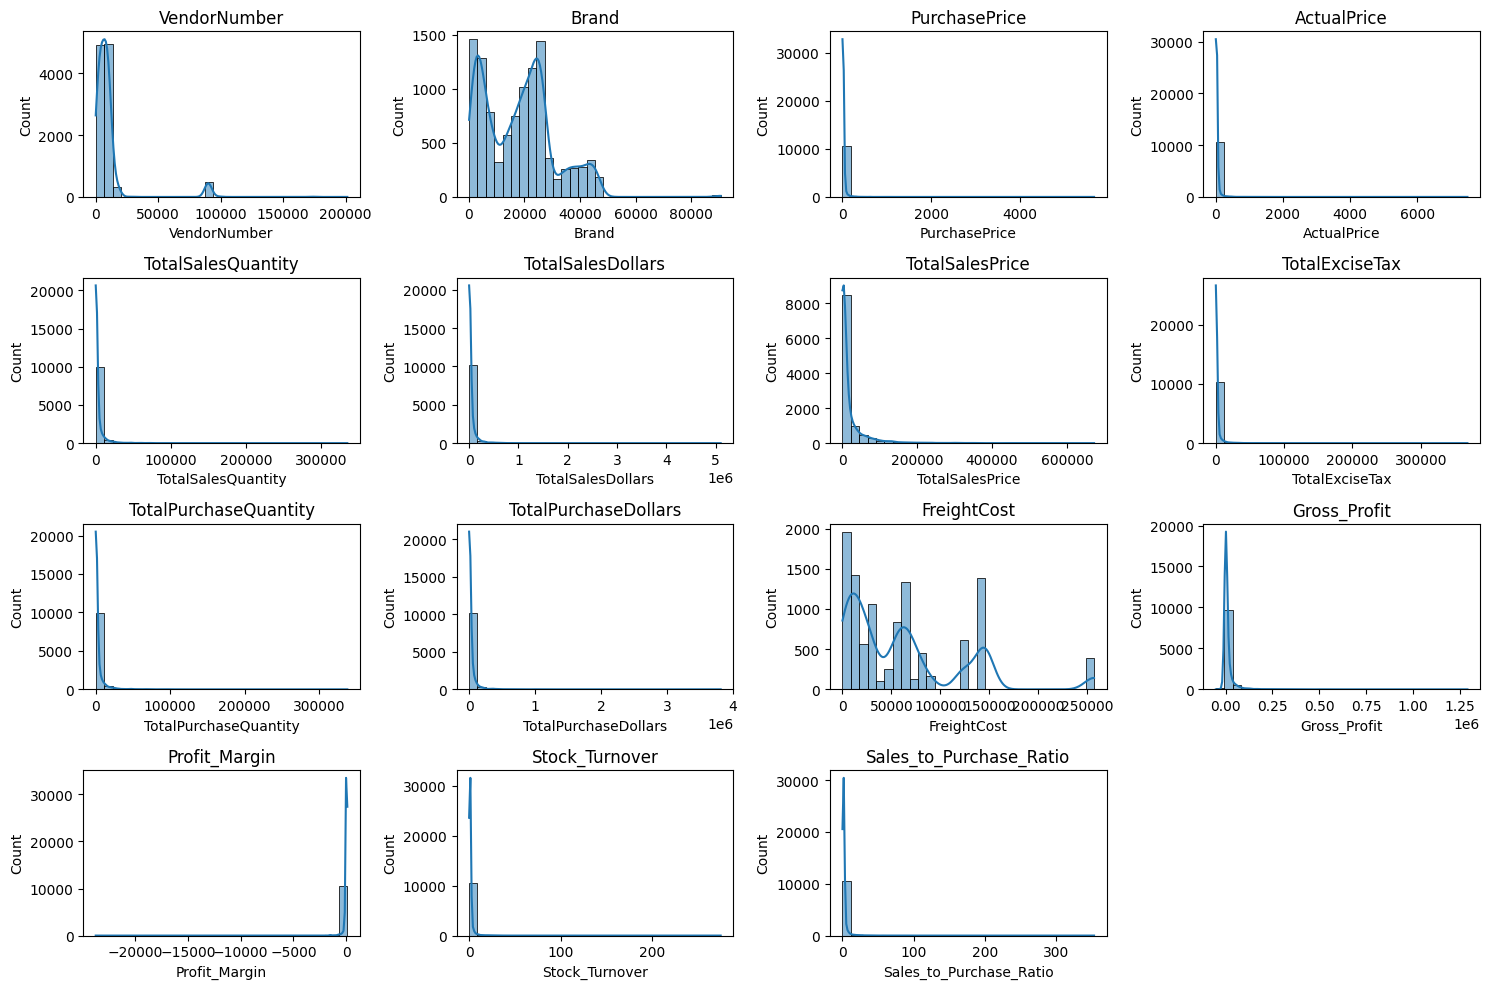

In [ ]:
# Distribution Plots for Numerical Columns
numerical_cols = df.select_dtypes (include=np.number).columns
plt.figure(figsize=(15, 10))
for i, col in enumerate (numerical_cols):
    plt.subplot(4, 4, i+1) # Adjust grid layout as needed
    sns.histplot(df [col], kde=True, bins=30)
    plt.title(col)
plt.tight_layout()
plt.show()

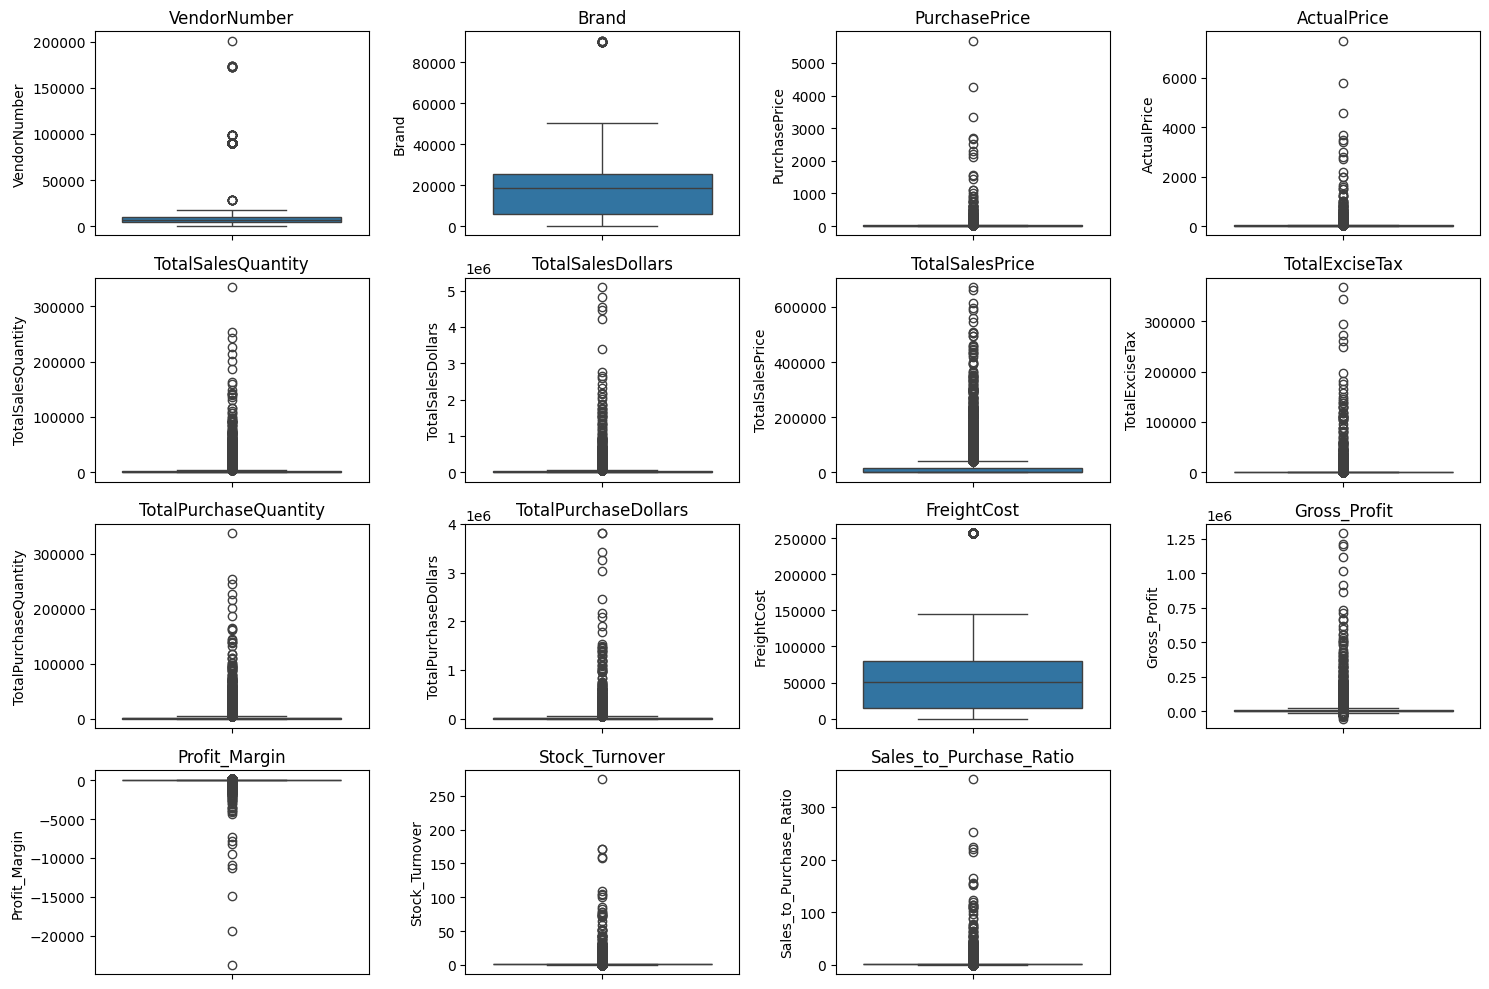

In [ ]:
# Outlier Detection with Boxplots

plt.figure(figsize=(15, 10))

for i, col in enumerate (numerical_cols):

    plt.subplot(4, 4, i+1)

    sns.boxplot(y=df [col])

    plt.title(col)

plt.tight_layout()

plt.show()

▼

Summary Statistics Insights:

Negative & Zero Values:

Gross Profit: Minimum value is -52,002.78, indicating losses. Some products or transactions may be selling at a loss due to high costs or selling at discounts lower than the purchase price..

Profit Margin: Has a minimum of-00, which suggests cases where revenue is zero or even lower than costs.

Total Sales Quantity & Sales Dollars: Minimum values are 0, meaning some products were purchased but never sold. These could be slow-moving or obsolete stock.

Outliers Indicated by High Standard Deviations:

Purchase & Actual Prices: The max values (5,681.81 & 7,499.99) are significantly higher than the mean (24.39 & 35.64), indicating potential premium products.

Freight Cost: Huge variation, from 0.09 to 257,032.07, suggests logistics inefficiencies or bulk shipments.

Stock Turnover: Ranges from 0 to 274.5, implying some products sell extremely fast while others remain in stock indefinitely. Value more than 1 indicates that Sold quantity for that product is higher than purchased quantity due to either sales are being fulfilled from older stock.

In [ ]:
# let's filter the data by removing inconsistencies

df = pd.read_sql_query("""SELECT *

FROM vendor_sales_summary

WHERE Gross_Profit > 0

AND Profit_Margin > 0

AND TotalSalesQuantity > 0""", conn)
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,TotalPurchaseQuantity,TotalPurchaseDollars,FreightCost,Gross_Profit,Profit_Margin,Stock_Turnover,Sales_to_Purchase_Ratio
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,23.86,36.99,18.0,665.82,295.92,2.00,8,190.88,27.08,474.94,71.331591,2.250000,3.488160
1,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,11.44,14.99,47.0,704.53,494.67,37.01,39,446.16,367.52,258.37,36.672675,1.205128,1.579097
2,105,ALTAMAR BRANDS LLC,2529,Right Gin,23.25,29.99,12.0,359.88,59.98,9.44,12,279.00,62.39,80.88,22.474158,1.000000,1.289892
3,105,ALTAMAR BRANDS LLC,8412,Tequila Ocho Plata Fresno,35.71,49.99,307.0,15346.93,12947.41,242.15,320,11427.20,62.39,3919.73,25.540808,0.959375,1.343018
4,200,AMERICAN SPIRITS EXCHANGE,20789,Zin-phomaniac Znfdl,9.73,14.99,84.0,1511.16,287.84,9.43,96,934.08,6.19,577.08,38.187882,0.875000,1.617806
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,172662,SWEETWATER FARM,2191,Clark & Chesterfield Whiskey,14.70,19.99,125.0,2498.75,1819.09,49.00,138,2028.60,178.34,470.15,18.815408,0.905797,1.231761
8560,172662,SWEETWATER FARM,2265,Monadnock Moonshine,21.47,28.99,222.0,6435.78,5363.15,175.13,267,5732.49,178.34,703.29,10.927813,0.831461,1.122685
8561,172662,SWEETWATER FARM,3632,Ashuelot Vodka,21.58,28.49,452.0,12877.48,8205.12,356.14,554,11955.32,178.34,922.16,7.161028,0.815884,1.077134
8562,173357,TAMWORTH DISTILLING,3909,White Mountain Vodka,19.37,24.99,982.0,24540.18,14469.21,773.87,1232,23863.84,202.50,676.34,2.756052,0.797078,1.028342


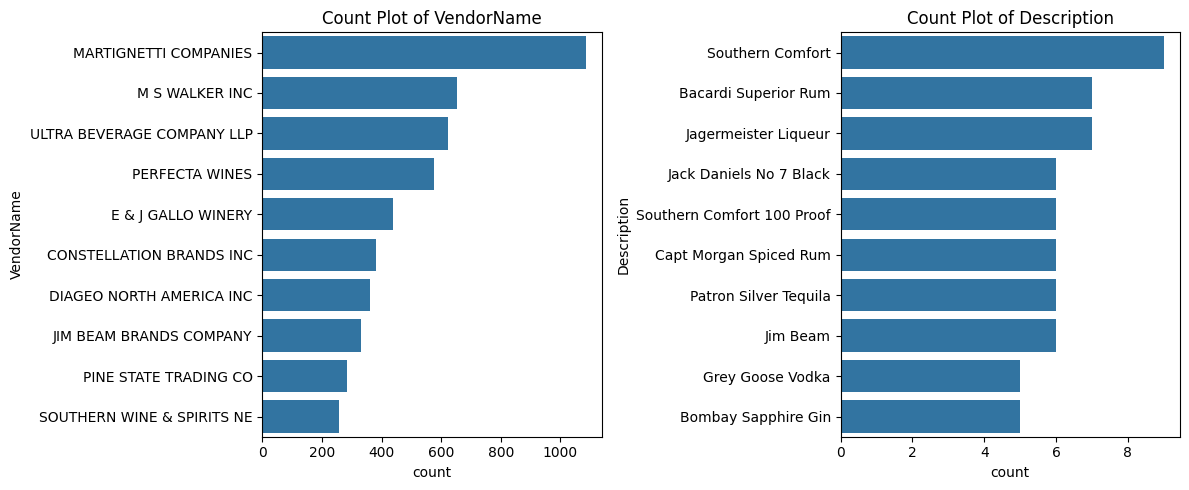

In [ ]:
# Count Plots for Categorical Columns

categorical_cols = ["VendorName", "Description"]

plt.figure(figsize=(12, 5))

for i, col in enumerate (categorical_cols):

    plt.subplot(1, 2, i+1)

    sns.countplot(y=df [col], order=df [col].value_counts().index[:10]) #top 10 categories
    plt.title(f"Count Plot of {col}")

plt.tight_layout()

plt.show()

Correlation Insights

PurchasePrice has weak correlations with TotalSalesDollars (-0.012) and GrossProfit (-0.016), suggesting that price variations do not significantly impact sales revenue or profit

Strong correlation between total purchase quantity and total sales quantity (0.999), confirming efficient inventory turnover.

Negative correlation between profit margin & total sales price (-0.179) suggests that as sales price increases, margins decrease, possibly due to competitive pricing pressures.

StockTurnover has weak negative correlations with both GrossProfit (-0.038) and ProfitMargin (-0.055), indicating that faster turnover does not necessaril result in higher profitability.

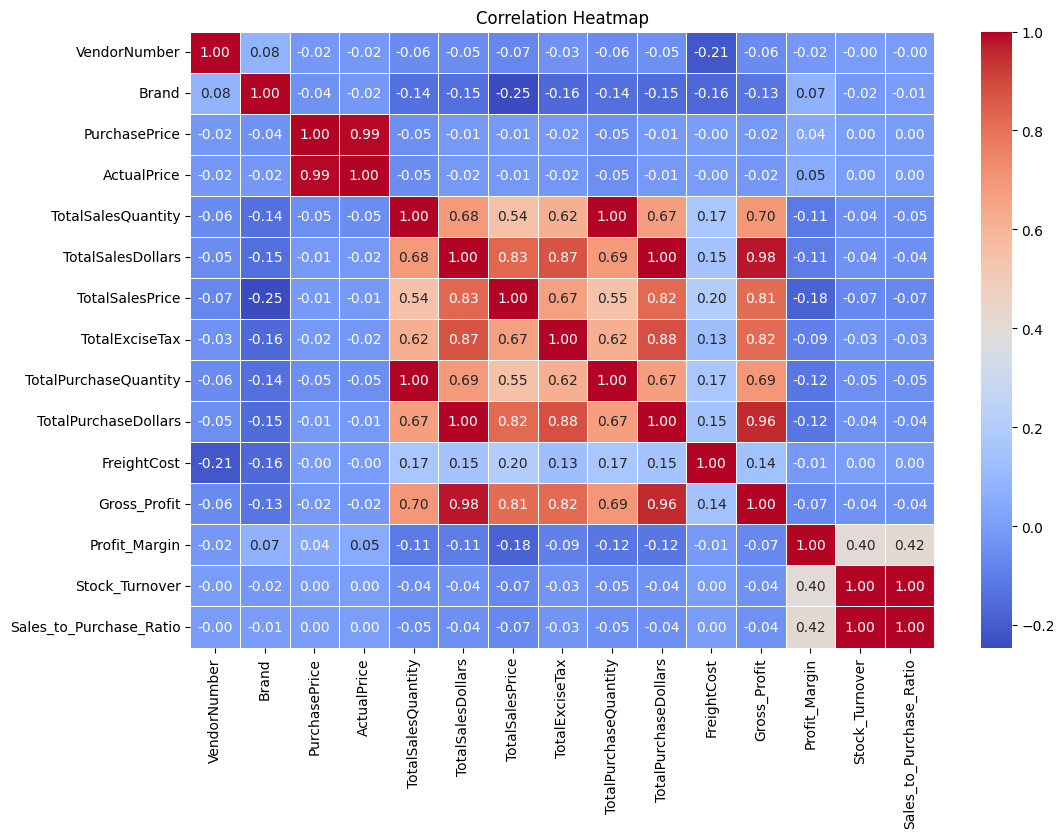

In [ ]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

correlation_matrix = df [numerical_cols].corr()

sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)

plt.title("Correlation Heatmap")

plt.show()

DATA ANALYSIS
Identify brands that needs promotional or pricing adjustments which exhibit lower sales performance but higher profit margins

In [ ]:
brand_performance=df.groupby('Description').agg({
    'TotalSalesDollars':"sum",
    "Profit_Margin":"mean"
}).reset_index()

In [ ]:
low_sales_threshold=brand_performance['TotalSalesDollars'].quantile(0.15)
high_margin_threshold=brand_performance['Profit_Margin'].quantile(0.85)



In [ ]:
low_sales_threshold

np.float64(560.299)

In [ ]:
high_margin_threshold

np.float64(64.97017552750113)

In [ ]:
# Filter brands with low sales but high profit margins

target_brands = brand_performance [
(brand_performance ['TotalSalesDollars'] <= low_sales_threshold) &
(brand_performance ['Profit_Margin'] >= high_margin_threshold)
]
print("Brands with Low Sales but High Profit Margins:")
display(target_brands.sort_values('TotalSalesDollars'))

Brands with Low Sales but High Profit Margins:


,Description,TotalSalesDollars,Profit_Margin
6199,Santa Rita Organic Svgn Bl,9.99,66.466466
2369,Debauchery Pnt Nr,11.58,65.975820
2070,Concannon Glen Ellen Wh Zin,15.95,83.448276
2188,Crown Royal Apple,27.86,89.806174
6237,Sauza Sprklg Wild Berry Marg,27.96,82.153076
...,...,...,...
5074,Nanbu Bijin Southern Beauty,535.68,76.747312
2271,Dad's Hat Rye Whiskey,538.89,81.851584
57,A Bichot Clos Marechaudes,539.94,67.740860
6245,Sbragia Home Ranch Merlot,549.75,66.444748


In [ ]:
brand_performance=brand_performance[brand_performance['TotalSalesDollars']<10000]

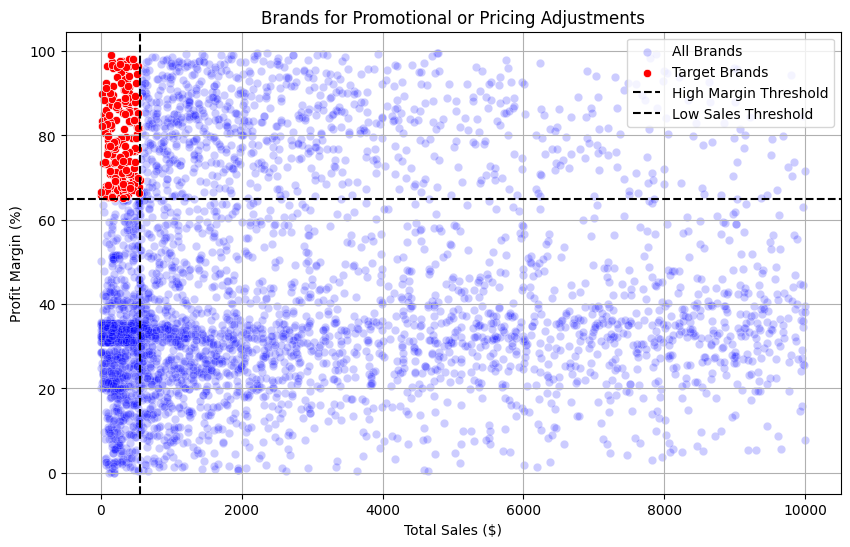

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=brand_performance, x='TotalSalesDollars', y='Profit_Margin', color="blue", label="All Brands", alpha= 0.2)
sns.scatterplot(data=target_brands, x='TotalSalesDollars', y='Profit_Margin', color="red", label="Target Brands")
plt.axhline(high_margin_threshold, linestyle='--', color='black', label="High Margin Threshold")
plt.axvline(low_sales_threshold, linestyle='--', color='black', label="Low Sales Threshold")
plt.xlabel("Total Sales ($)")
plt.ylabel("Profit Margin (%)")
plt.title("Brands for Promotional or Pricing Adjustments")
plt.legend()
plt.grid(True)

plt.show()

which vendors and brands demonstrate the highest sales performance?

In [ ]:
# Top Vendors & Brands by Sales Performance

top_vendors = df.groupby("VendorName") ["TotalSalesDollars"].sum().nlargest(10)
top_brands = df.groupby("Description") ["TotalSalesDollars"].sum().nlargest(10)

top_vendors

VendorName
DIAGEO NORTH AMERICA INC      67990099.42
MARTIGNETTI COMPANIES         39330359.36
PERNOD RICARD USA             32063196.19
JIM BEAM BRANDS COMPANY       31423020.46
BACARDI USA INC               24854817.14
CONSTELLATION BRANDS INC      24218745.65
E & J GALLO WINERY            18399899.46
BROWN-FORMAN CORP             18247230.65
ULTRA BEVERAGE COMPANY LLP    16502544.31
M S WALKER INC                14706458.51
Name: TotalSalesDollars, dtype: float64

In [ ]:
top_brands

Description
Jack Daniels No 7 Black    7964746.76
Tito's Handmade Vodka      7399657.58
Grey Goose Vodka           7209608.06
Capt Morgan Spiced Rum     6356320.62
Absolut 80 Proof           6244752.03
Jameson Irish Whiskey      5715759.69
Ketel One Vodka            5070083.56
Baileys Irish Cream        4150122.07
Kahlua                     3604858.66
Tanqueray                  3456697.90
Name: TotalSalesDollars, dtype: float64

In [ ]:
def format_dollars (value):

    if value >= 1_000_000:

        return f"{value / 1_000_000:.2f}M"

    elif value >= 1_000:

        return f"{value / 1_000:.2f}K"

    else:

        return str(value)

In [ ]:
top_brands.apply(lambda x:format_dollars(x))

Description
Jack Daniels No 7 Black    7.96M
Tito's Handmade Vodka      7.40M
Grey Goose Vodka           7.21M
Capt Morgan Spiced Rum     6.36M
Absolut 80 Proof           6.24M
Jameson Irish Whiskey      5.72M
Ketel One Vodka            5.07M
Baileys Irish Cream        4.15M
Kahlua                     3.60M
Tanqueray                  3.46M
Name: TotalSalesDollars, dtype: str

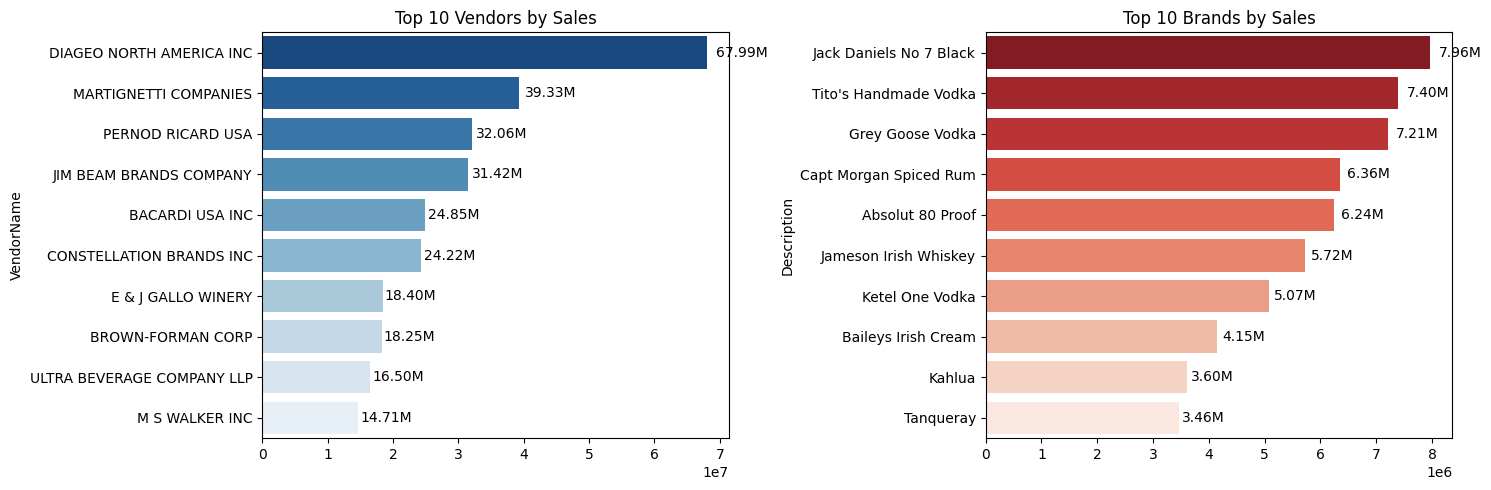

In [ ]:
plt.figure(figsize=(15, 5))

# Plot for Top Vendors

plt.subplot(1, 2, 1)

ax1 = sns.barplot(y=top_vendors.index, x=top_vendors.values, palette="Blues_r")
plt.title("Top 10 Vendors by Sales")

for bar in ax1.patches:

    ax1.text(bar.get_width() + (bar.get_width() * 0.02), 
           bar.get_y() + bar.get_height() / 2, 
           format_dollars(bar.get_width()),
           ha='left', va='center', fontsize=10, color='black')

# Plot for Top Brands

plt.subplot(1, 2, 2)
ax2 = sns.barplot(y=top_brands.index.astype(str),
                  x=top_brands.values, 
                  palette="Reds_r")

plt.title("Top 10 Brands by Sales")

for bar in ax2.patches:
    ax2.text(bar.get_width() + (bar.get_width() * 0.02),             
    bar.get_y() + bar.get_height() / 2,
    format_dollars(bar.get_width()),
    ha='left', va='center', fontsize=10, color='black')


plt.tight_layout()

plt.show()

which vendors contribute the most to total purchase dollars?

In [ ]:
vendor_performance=df.groupby('VendorName').agg({
'TotalPurchaseDollars': 'sum',
'Gross_Profit':'sum',
'TotalSalesDollars': 'sum'
}).reset_index()

vendor_performance

,VendorName,TotalPurchaseDollars,Gross_Profit,TotalSalesDollars
0,ADAMBA IMPORTS INTL INC,446.16,258.37,704.53
1,ALISA CARR BEVERAGES,25698.12,78772.82,104470.94
2,ALTAMAR BRANDS LLC,11706.20,4000.61,15706.81
3,AMERICAN SPIRITS EXCHANGE,934.08,577.08,1511.16
4,AMERICAN VINTAGE BEVERAGE,104435.68,35167.85,139603.53
...,...,...,...,...
114,WEIN BAUER INC,42694.64,13522.49,56217.13
115,WESTERN SPIRITS BEVERAGE CO,298416.86,106837.97,405254.83
116,WILLIAM GRANT & SONS INC,5876538.26,1693337.94,7569876.20
117,WINE GROUP INC,5203801.17,3100242.11,8304043.28


In [ ]:
vendor_performance['PurchaseContribution%']=(vendor_performance['TotalPurchaseDollars'] / vendor_performance['TotalPurchaseDollars'].sum())*100
vendor_performance

,VendorName,TotalPurchaseDollars,Gross_Profit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50097226.16,17892873.26,67990099.42,16.300345
57,MARTIGNETTI COMPANIES,25502095.83,13828263.53,39330359.36,8.297724
68,PERNOD RICARD USA,23851164.17,8212032.02,32063196.19,7.760554
46,JIM BEAM BRANDS COMPANY,23494304.32,7928716.14,31423020.46,7.644441
6,BACARDI USA INC,17432020.26,7422796.88,24854817.14,5.671930
...,...,...,...,...,...
33,FANTASY FINE WINES CORP,128.64,198.95,327.59,0.000042
107,UNCORKED,118.74,58.20,176.94,0.000039
85,SILVER MOUNTAIN CIDERS,77.18,265.33,342.51,0.000025
16,CAPSTONE INTERNATIONAL,54.64,192.23,246.87,0.000018


In [ ]:
vendor_performance=round(vendor_performance.sort_values('PurchaseContribution%', ascending=False), 2)
vendor_performance

,VendorName,TotalPurchaseDollars,Gross_Profit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50097226.16,17892873.26,67990099.42,16.30
57,MARTIGNETTI COMPANIES,25502095.83,13828263.53,39330359.36,8.30
68,PERNOD RICARD USA,23851164.17,8212032.02,32063196.19,7.76
46,JIM BEAM BRANDS COMPANY,23494304.32,7928716.14,31423020.46,7.64
6,BACARDI USA INC,17432020.26,7422796.88,24854817.14,5.67
...,...,...,...,...,...
33,FANTASY FINE WINES CORP,128.64,198.95,327.59,0.00
107,UNCORKED,118.74,58.20,176.94,0.00
85,SILVER MOUNTAIN CIDERS,77.18,265.33,342.51,0.00
16,CAPSTONE INTERNATIONAL,54.64,192.23,246.87,0.00


In [ ]:
# Display Top 10 Vendors

top_vendors =vendor_performance.head(10)
top_vendors ['TotalSalesDollars'] = top_vendors ['TotalSalesDollars'].apply(format_dollars)
top_vendors ['TotalPurchaseDollars'] = top_vendors ['TotalPurchaseDollars'].apply(format_dollars)
top_vendors ['Gross_Profit'] = top_vendors ['Gross_Profit'].apply(format_dollars)
top_vendors

,VendorName,TotalPurchaseDollars,Gross_Profit,TotalSalesDollars,PurchaseContribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18


In [ ]:
top_vendors['Cumulative_contribution%']=top_vendors['PurchaseContribution%'].cumsum()
top_vendors


,VendorName,TotalPurchaseDollars,Gross_Profit,TotalSalesDollars,PurchaseContribution%,Cumulative_contribution%
25,DIAGEO NORTH AMERICA INC,50.10M,17.89M,67.99M,16.30,16.30
57,MARTIGNETTI COMPANIES,25.50M,13.83M,39.33M,8.30,24.60
68,PERNOD RICARD USA,23.85M,8.21M,32.06M,7.76,32.36
46,JIM BEAM BRANDS COMPANY,23.49M,7.93M,31.42M,7.64,40.00
6,BACARDI USA INC,17.43M,7.42M,24.85M,5.67,45.67
20,CONSTELLATION BRANDS INC,15.27M,8.95M,24.22M,4.97,50.64
11,BROWN-FORMAN CORP,13.24M,5.01M,18.25M,4.31,54.95
30,E & J GALLO WINERY,12.07M,6.33M,18.40M,3.93,58.88
106,ULTRA BEVERAGE COMPANY LLP,11.17M,5.34M,16.50M,3.63,62.51
53,M S WALKER INC,9.76M,4.94M,14.71M,3.18,65.69


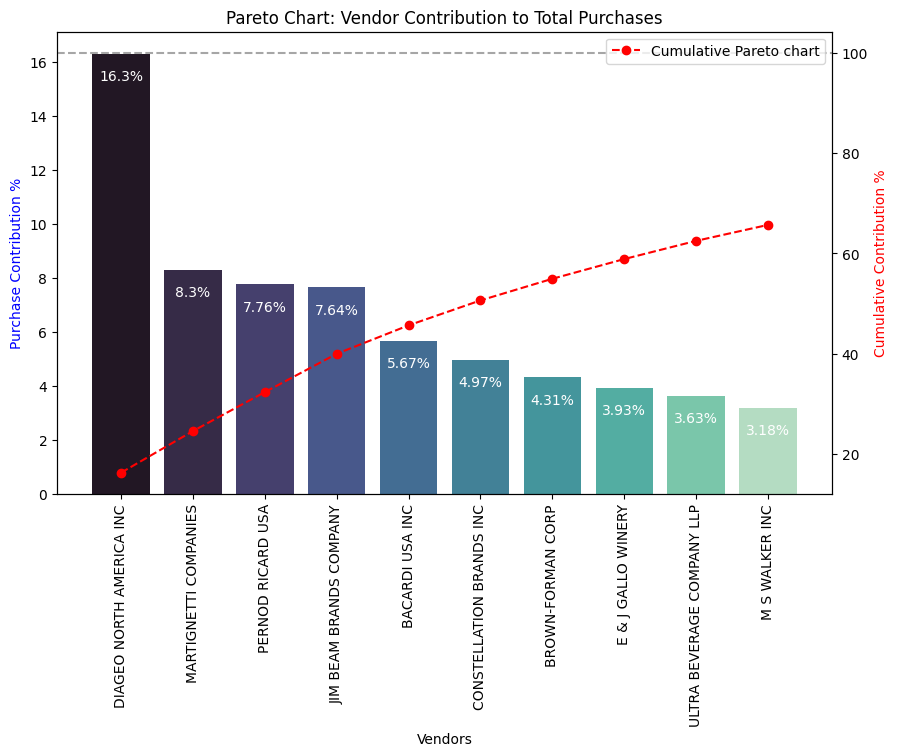

In [ ]:
fig,ax1 = plt.subplots(figsize=(10, 6))

# Bar plot for Purchase Contribution%

sns.barplot(x=top_vendors ['VendorName'], y=top_vendors ['PurchaseContribution%'], palette="mako", ax=ax1)

for i, value in enumerate (top_vendors ['PurchaseContribution%']):

    ax1.text(i, value-1, str(value)+'%', ha='center', fontsize=10, color='white')

# Line Plot for Cumulative Contribution%

ax2 = ax1.twinx()

ax2.plot(top_vendors ['VendorName'], top_vendors ['Cumulative_contribution%'], color='red', marker='o', linestyle='dashed', label='Cumulative Pareto chart')

ax1.set_xticklabels (top_vendors ['VendorName'], rotation=90)

ax1.set_ylabel('Purchase Contribution %', color='blue')

ax2.set_ylabel('Cumulative Contribution %', color='red')

ax1.set_xlabel('Vendors')

ax1.set_title('Pareto Chart: Vendor Contribution to Total Purchases')

ax2.axhline(y=100, color='gray', linestyle='dashed', alpha=0.7)

ax2. legend (loc='upper right')

plt.show()



How much of total procurement is dependent on the top vendors?

In [ ]:
print(f"Total Purchase Contribution of top 10 vendors is {round(top_vendors ['PurchaseContribution%'].sum(),2)} %")

Total Purchase Contribution of top 10 vendors is 65.69 %


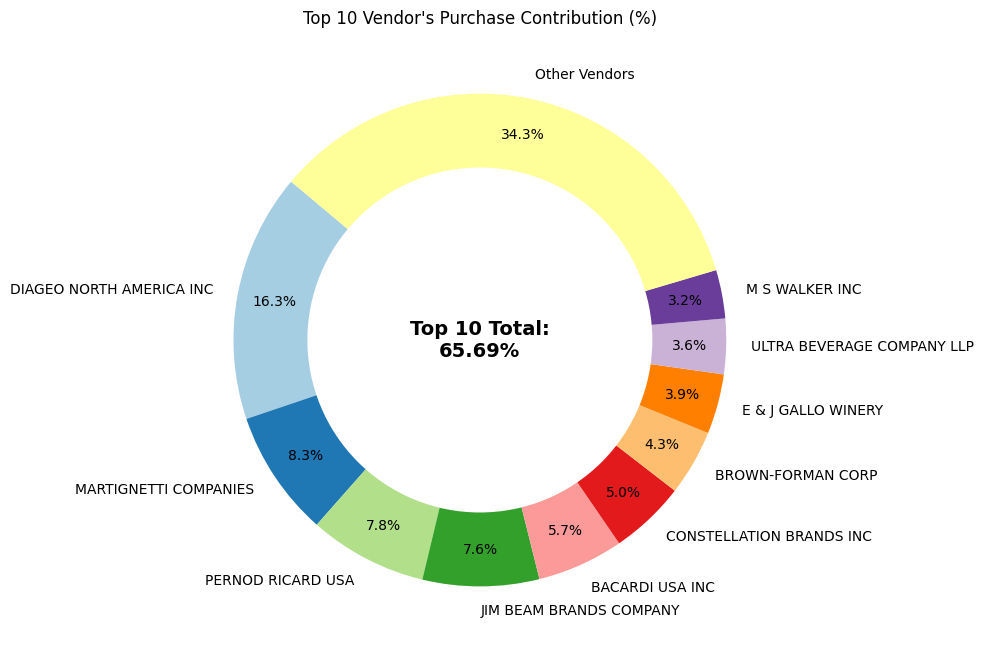

In [ ]:
vendors=list(top_vendors ['VendorName'].values)
purchase_contributions=list(top_vendors ['PurchaseContribution%'].values)
total_contribution = sum(purchase_contributions)
remaining_contribution = 100-total_contribution

#Append "Other Vendors" category
vendors.append("Other Vendors")
purchase_contributions.append(remaining_contribution)

# Donut Chart
fig, ax = plt.subplots(figsize=(8, 8))
wedges, texts, autotexts = ax.pie (purchase_contributions, labels=vendors, autopct='%1.1f%%',
                                    startangle=140, pctdistance=0.85, colors=plt.cm.Paired.colors)

# Draw a white circle in the center to create a "donut" effect
centre_circle = plt. Circle ((0, 0), 0.70, fc='white')
fig.gca().add_artist(centre_circle)

# Add Total Contribution annotation in the center
plt.text(0, 0, f"Top 10 Total:\n{total_contribution:.2f}%", fontsize=14, fontweight='bold', ha='center', va='center')
plt.title("Top 10 Vendor's Purchase Contribution (%)")

plt.show()

Does purchasing in bulk reduce the unit price,and what is the optimal purchase volume for cost savings?

In [ ]:
df ['UnitPurchasePrice'] = df ['TotalPurchaseDollars'] /df ['TotalPurchaseQuantity']

In [ ]:
df ["OrderSize"] = pd.qcut(df ["TotalPurchaseQuantity"], q=3, labels=["Small", "Medium", "Large"])
df

,VendorNumber,VendorName,Brand,Description,PurchasePrice,ActualPrice,TotalSalesQuantity,TotalSalesDollars,TotalSalesPrice,TotalExciseTax,TotalPurchaseQuantity,TotalPurchaseDollars,FreightCost,Gross_Profit,Profit_Margin,Stock_Turnover,Sales_to_Purchase_Ratio,UnitPurchasePrice,OrderSize
0,2,"IRA GOLDMAN AND WILLIAMS, LLP",90085,Ch Lilian 09 Ladouys St Este,23.86,36.99,18.0,665.82,295.92,2.00,8,190.88,27.08,474.94,71.331591,2.250000,3.488160,23.86,Small
1,60,ADAMBA IMPORTS INTL INC,771,Bak's Krupnik Honey Liqueur,11.44,14.99,47.0,704.53,494.67,37.01,39,446.16,367.52,258.37,36.672675,1.205128,1.579097,11.44,Small
2,105,ALTAMAR BRANDS LLC,2529,Right Gin,23.25,29.99,12.0,359.88,59.98,9.44,12,279.00,62.39,80.88,22.474158,1.000000,1.289892,23.25,Small
3,105,ALTAMAR BRANDS LLC,8412,Tequila Ocho Plata Fresno,35.71,49.99,307.0,15346.93,12947.41,242.15,320,11427.20,62.39,3919.73,25.540808,0.959375,1.343018,35.71,Medium
4,200,AMERICAN SPIRITS EXCHANGE,20789,Zin-phomaniac Znfdl,9.73,14.99,84.0,1511.16,287.84,9.43,96,934.08,6.19,577.08,38.187882,0.875000,1.617806,9.73,Medium
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8559,172662,SWEETWATER FARM,2191,Clark & Chesterfield Whiskey,14.70,19.99,125.0,2498.75,1819.09,49.00,138,2028.60,178.34,470.15,18.815408,0.905797,1.231761,14.70,Medium
8560,172662,SWEETWATER FARM,2265,Monadnock Moonshine,21.47,28.99,222.0,6435.78,5363.15,175.13,267,5732.49,178.34,703.29,10.927813,0.831461,1.122685,21.47,Medium
8561,172662,SWEETWATER FARM,3632,Ashuelot Vodka,21.58,28.49,452.0,12877.48,8205.12,356.14,554,11955.32,178.34,922.16,7.161028,0.815884,1.077134,21.58,Medium
8562,173357,TAMWORTH DISTILLING,3909,White Mountain Vodka,19.37,24.99,982.0,24540.18,14469.21,773.87,1232,23863.84,202.50,676.34,2.756052,0.797078,1.028342,19.37,Medium


In [ ]:
df.groupby('OrderSize')[['UnitPurchasePrice']].mean()

,UnitPurchasePrice
OrderSize,
Small,39.068186
Medium,15.486414
Large,10.777625


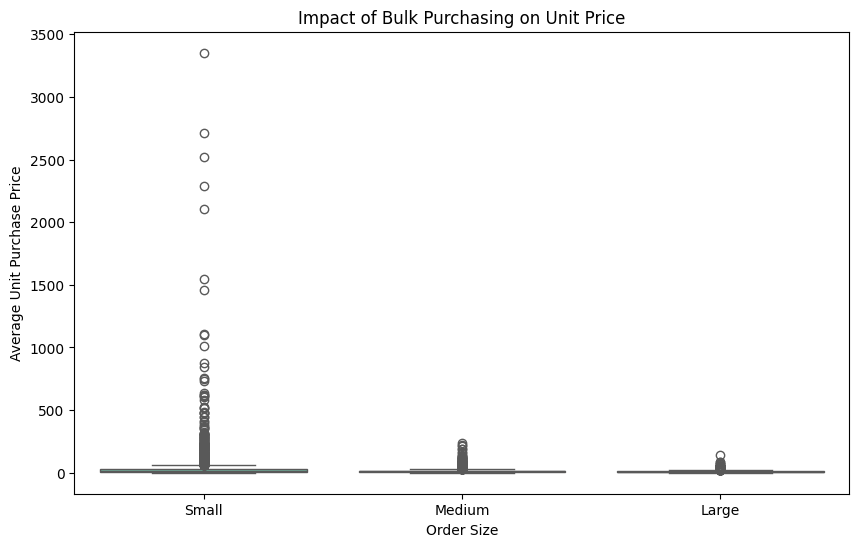

In [ ]:
plt.figure(figsize=(10, 6))

sns.boxplot(data=df, x="OrderSize", y="UnitPurchasePrice", palette="Set2")

plt.title("Impact of Bulk Purchasing on Unit Price")

plt.xlabel("Order Size")

plt.ylabel("Average Unit Purchase Price")

plt.show()

Vendors buying in bulk (Large Order Size) get the lowest unit price ($10.78 per unit), mearing higher margins if they can manage inventory efficiently.

The price difference between Small and Large orders is substantial (~72% reduction in unit cost)

This suggests that bulk pricing strategies successfully encourage vendors to purchase in larger volumes, leading to higher overall sales despite lower per-unit revenue.

which vendors have low inventory turnover,indicating excess stock and slow-moving products?

In [ ]:
df[df['Stock_Turnover']<1].groupby('VendorName')[['Stock_Turnover']].mean().sort_values('Stock_Turnover').head(10)

,Stock_Turnover
VendorName,
ALISA CARR BEVERAGES,0.615385
HIGHLAND WINE MERCHANTS LLC,0.708333
PARK STREET IMPORTS LLC,0.751306
Circa Wines,0.755676
Dunn Wine Brokers,0.766022
CENTEUR IMPORTS LLC,0.773953
SMOKY QUARTZ DISTILLERY LLC,0.783835
TAMWORTH DISTILLING,0.797078
THE IMPORTED GRAPE LLC,0.807569


How much capital is locked in unsold inventory per vendor, and which vendors contribute the most to it

In [ ]:
df ["UnsoldInventoryValue"] = (df ["TotalPurchaseQuantity"] - df ["TotalSalesQuantity"]) * df ["PurchasePrice"]

print('Total Unsold Capital:', format_dollars (df ["UnsoldInventoryValue"].sum()))

Total Unsold Capital: 2.71M


In [ ]:
#Aggregate Capital Locked per Vendor
inventory_value_per_vendor = df.groupby("VendorName") ["UnsoldInventoryValue"].sum().reset_index()

# Sort Vendors with the Highest Locked Capital
inventory_value_per_vendor = inventory_value_per_vendor.sort_values (by="UnsoldInventoryValue", ascending=False) 
inventory_value_per_vendor['UnsoldInventoryValue'] = inventory_value_per_vendor ['UnsoldInventoryValue'].apply(format_dollars)
inventory_value_per_vendor.head(10)

,VendorName,UnsoldInventoryValue
25,DIAGEO NORTH AMERICA INC,722.21K
46,JIM BEAM BRANDS COMPANY,554.67K
68,PERNOD RICARD USA,470.63K
116,WILLIAM GRANT & SONS INC,401.96K
30,E & J GALLO WINERY,228.28K
79,SAZERAC CO INC,198.44K
11,BROWN-FORMAN CORP,177.73K
20,CONSTELLATION BRANDS INC,133.62K
61,MOET HENNESSY USA INC,126.48K
77,REMY COINTREAU USA INC,118.60K


what is the 95% confidence interval for profit margins of top performing and low-performing vendors

In [ ]:
top_threshold = df["TotalSalesDollars"].quantile(0.75)
low_threshold = df["TotalSalesDollars"].quantile(0.25)


In [ ]:
top_vendors = df[df["TotalSalesDollars"] >= top_threshold] ["Profit_Margin"].dropna()

low_vendors = df[df["TotalSalesDollars"] <= low_threshold] ["Profit_Margin"].dropna()

In [ ]:
top_vendors

5       16.999601
8       30.557678
13      30.827478
14      27.129385
17      24.329082
          ...    
8536    25.173464
8537    22.886164
8538    22.652408
8552    27.103538
8554    28.056879
Name: Profit_Margin, Length: 2141, dtype: float64

In [ ]:
low_vendors

0       71.331591
1       36.672675
2       22.474158
9       20.559532
10      64.915236
          ...    
8549    41.388657
8550    21.862972
8551    73.338465
8553    40.470235
8556    88.098999
Name: Profit_Margin, Length: 2141, dtype: float64

In [ ]:
def confidence_interval(data, confidence=0.95):
    mean_val = np.mean(data)
    std_err = np.std(data, ddof=1) / np.sqrt(len(data)) # Standard error
    t_critical = stats.t.ppf((1+ confidence) / 2, df=len(data) - 1)
    margin_of_error = t_critical * std_err
    return mean_val, mean_val-margin_of_error, mean_val + margin_of_error 

Top Vendors 95% CI: (30.74, 31.61), Mean: 31.18
Low Vendors 95% CI: (40.50, 42.64), Mean: 41.57


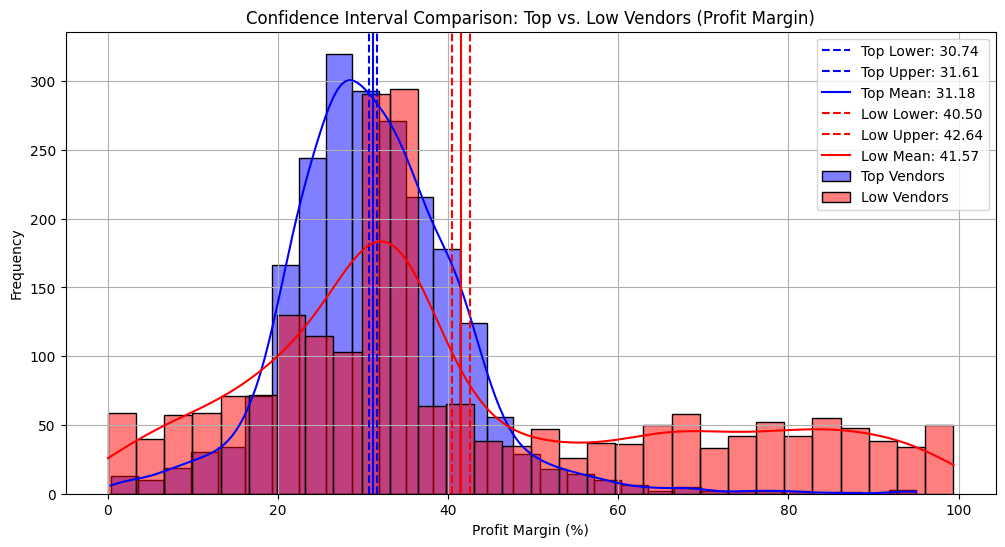

In [ ]:
top_mean, top_lower, top_upper = confidence_interval(top_vendors)
low_mean, low_lower, low_upper = confidence_interval(low_vendors)
print(f"Top Vendors 95% CI: ({top_lower:.2f}, {top_upper:.2f}), Mean: {top_mean:.2f}")
print(f"Low Vendors 95% CI: ({low_lower:.2f}, {low_upper:.2f}), Mean: {low_mean:.2f}")
plt.figure(figsize=(12, 6))

# Top Vendors Plot

sns.histplot(top_vendors, kde =True, color="blue", bins=30, alpha=0.5, label="Top Vendors")
plt.axvline(top_lower, color="blue", linestyle="--", label=f"Top Lower: {top_lower:.2f}")
plt.axvline(top_upper, color="blue", linestyle="--", label=f"Top Upper: {top_upper:.2f}")
plt.axvline(top_mean, color="blue", linestyle="-", label=f"Top Mean: {top_mean:.2f}")

# Low Vendors Plot

sns.histplot(low_vendors, kde =True, color="red", bins=30, alpha=0.5, label="Low Vendors")
plt.axvline(low_lower, color="red", linestyle="--", label=f"Low Lower: {low_lower:.2f}")
plt.axvline(low_upper, color="red", linestyle="--", label=f"Low Upper: {low_upper:.2f}")
plt.axvline(low_mean, color="red", linestyle="-", label=f"Low Mean: {low_mean:.2f}")

# Finalize Plot

plt.title("Confidence Interval Comparison: Top vs. Low Vendors (Profit Margin)")
plt.xlabel("Profit Margin (%)")
plt.ylabel("Frequency")
plt.legend()
plt.grid(True)  
plt.show()

The confidence interval for low-performing vendors (40.48% to 42.62%) is significantly higher than that of top-performing vendors (30.74% to 31.61%).

This suggests that vendors with lower sales tend to maintain higher profit margins, potentially due to premium pricing or lower operational costs.

For High-Performing Vendors: If they aim to improve profitability, they could explore selective price adjustments, cost optimization, or bundling strategies.

For Low-Performing Vendors: Despite higher margins, their low sales volume might indicate a need for better marketing, competitive pricing, or improved distribution strategies.

Is there a significant difference in profit margins between top-performing and low-performing vendors?

Hypothesis:

Ho (Null Hypothesis): There is no significant difference in the mean profit margins of top-performing and low-performing vendors.

H₁ (Alternative Hypothesis): The mean profit margins of top-performing and low-performing vendors are significantly different.

In [ ]:
top_threshold = df ["TotalSalesDollars"].quantile(0.75)

low_threshold = df ["TotalSalesDollars"].quantile(0.25)

top_vendors = df [df ["TotalSalesDollars"] >= top_threshold] ["Profit_Margin"].dropna()

low_vendors = df [df ["TotalSalesDollars"] <= low_threshold] ["Profit_Margin"].dropna()

# Perform Two-Sample T-Test

t_stat, p_value = ttest_ind(top_vendors, low_vendors, equal_var=False)

# Print results

print(f"T-Statistic: {t_stat:.4f}, P-Value: {p_value:.4f}")

if p_value < 0.05:

    print("Reject Ho: There is a significant difference in profit margins between top and low-performing vendors.")

else:

    print("Fail to Reject Ho: No significant difference in profit margins.")

T-Statistic: -17.6695, P-Value: 0.0000
Reject Ho: There is a significant difference in profit margins between top and low-performing vendors.


In [ ]:
# 1. Main summary table export
df.to_csv('vendor_sales_summary.csv', index=False)

# 2. Brand Performance table export
brand_performance.to_csv('BrandPerformance.csv', index=False)

# 3. Purchase Contribution (vendor_performance) export
# vendor_performance.to_csv('PurchaseContribution.csv', index=False)

# 4. Low Turnover Vendors table export (Pehle isko ek variable mein save karenge)
low_turnover_vendors = df[df['Stock_Turnover']<1].groupby('VendorName')[['Stock_Turnover']].mean().sort_values('Stock_Turnover').head(10).reset_index()
low_turnover_vendors.to_csv('LowTurnoverVendor.csv', index=False)

print("Success! Saari files physical CSV format mein aapke folder mein save ho gayi hain.")

NameError: name 'df' is not defined